<a href="https://colab.research.google.com/github/RonaldGarciaOvalle/Clase-extracci-n-de-objetos/blob/main/Extracci%C3%B3n_de_objetos_cuaderno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ÁREA CONSTRUIDA**

### **ENTORNO E INSUMOS**

In [ ]:
# 1. Instalar librerías indispensables de forma silenciosa
!pip install tensorflow rasterio geopandas gdown -q

# 2. Limpiar directorios previos para evitar mezclar datos viejos
!rm -rf /content/Datos_clase /content/SIG_AVANZADO.zip

# 3. Descargar y descomprimir directamente desde la terminal de Linux
print("Descargando e instalando insumos de clase...")
!gdown --id "13DLexVXVO0x56JB-OGoSS9H0s2hfOaYr" -O /content/SIG_AVANZADO.zip
!unzip -q -o /content/SIG_AVANZADO.zip -d /content/

print("¡Entorno configurado con éxito!")

Descargando e instalando insumos de clase...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=13DLexVXVO0x56JB-OGoSS9H0s2hfOaYr
From (redirected): https://drive.google.com/uc?id=13DLexVXVO0x56JB-OGoSS9H0s2hfOaYr&confirm=t&uuid=0df3b829-aca7-4970-a438-cdd43dfc754b
To: /content/SIG_AVANZADO.zip
100% 582M/582M [00:04<00:00, 119MB/s] 
¡Entorno configurado con éxito!


## **PREDICCIÓN E INFERENCIA DE ÁREA CONSTRUIDA**

Cargando modelo de Inteligencia Artificial...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(



Ejecutando inferencia por ventanas...


Filas: 100%|██████████| 5/5 [03:58<00:00, 47.63s/it]



================ METRICAS PLANETARICA ================
Precisión (Precision):   0.8845
Exhaustividad (Recall):   0.9030
F1-Score Global:          0.8936


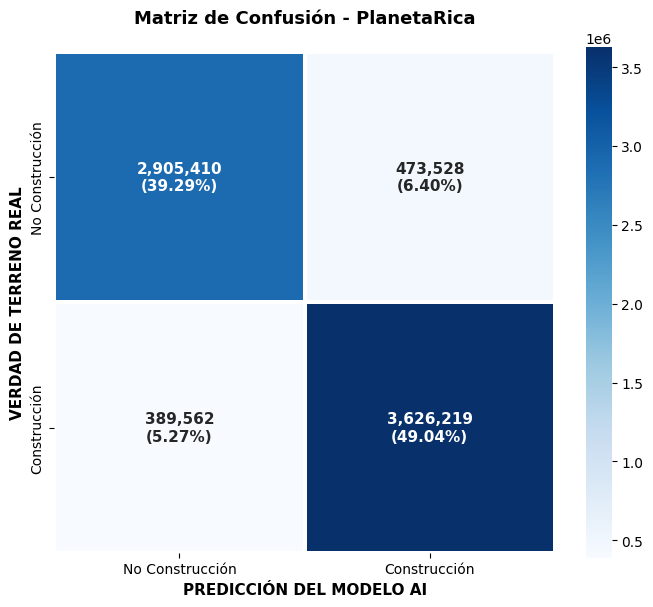

In [ ]:
import os
import cv2
import numpy as np
import rasterio
import geopandas as gpd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from tqdm import tqdm
from rasterio.mask import geometry_mask
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from keras.src.layers.convolutional.conv2d_transpose import Conv2DTranspose

# 0. PARCHE DE COMPATIBILIDAD KERAS 3
if not hasattr(Conv2DTranspose, '_original_from_config_safe'):
    Conv2DTranspose._original_from_config_safe = Conv2DTranspose.from_config
    @classmethod
    def patched_from_config(cls, config):
        if 'groups' in config: config.pop('groups')
        return cls._original_from_config_safe(config)
    Conv2DTranspose.from_config = patched_from_config

# 1. FUNCIONES DE PÉRDIDA Y MÉTRICAS PERSONALIZADAS
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f, y_pred_f = K.flatten(y_true), K.flatten(y_pred)
    return (2. * K.sum(y_true_f * y_pred_f) + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    return bce(y_true, y_pred) + (1 - dice_coef(y_true, y_pred))

CUSTOM_OBJECTS = {
    'dice_coef': dice_coef,
    'dice_loss': lambda yt, yp: 1 - dice_coef(yt, yp),
    'bce_dice_loss': bce_dice_loss,
    'IoU': tf.keras.metrics.MeanIoU(num_classes=2, name='IoU')
}

# 2. CONFIGURACIÓN DE RUTAS Y PARÁMETROS
BASE_DIR = '/content/Datos_clase'
model_path = os.path.join(BASE_DIR, 'Modelos/Construcciones/best_model.h5')
tif_path = os.path.join(BASE_DIR, 'Datos/Imagen/PlanetaRica_clip_resamp.tif')
shapefile_truth_path = os.path.join(BASE_DIR, 'Datos/Vectores/Construccion_clip_PR.shp')
output_dir = os.path.join(BASE_DIR, 'Resultados_Construcciones')
os.makedirs(output_dir, exist_ok=True)

tesela_size = 512
BINARIZATION_THRESHOLD = 0.3
nombre_escena = os.path.basename(tif_path).split('_')[0]

print("Cargando modelo de Inteligencia Artificial...")
model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS)

# 3. LECTURA GEOGRÁFICA Y GENERACIÓN DE MÁSCARAS (VERDAD DE TERRENO Y NODATA)
with rasterio.open(tif_path) as src:
    bands = src.read()
    transform, crs = src.transform, src.crs

input_image = np.stack((bands[2], bands[1], bands[0]), axis=-1).astype(np.float32) / 255.0
height, width, _ = input_image.shape
non_data_mask = (bands[0] == 0) & (bands[1] == 0) & (bands[2] == 0)

truth_gdf = gpd.read_file(shapefile_truth_path)
if truth_gdf.crs != crs: truth_gdf = truth_gdf.to_crs(crs)
truth_mask = geometry_mask([g for g in truth_gdf.geometry], out_shape=(height, width), transform=transform, invert=True).astype(np.uint8)

# 4. INFERENCIA ESPACIAL CON CONTROL DE BORDES (PADDING)
pad_y = (tesela_size - (height % tesela_size)) % tesela_size
pad_x = (tesela_size - (width % tesela_size)) % tesela_size
padded_image = np.pad(input_image, ((0, pad_y), (0, pad_x), (0, 0)), mode='constant')
p_height, p_width, _ = padded_image.shape
padded_predictions = np.zeros((p_height, p_width), dtype=np.float32)

print("\nEjecutando inferencia por ventanas...")
for y in tqdm(range(0, p_height, tesela_size), desc="Filas"):
    for x in range(0, p_width, tesela_size):
        tesela = padded_image[y:y+tesela_size, x:x+tesela_size]
        if tesela.shape[:2] == (tesela_size, tesela_size):
            pred_prob = model.predict(np.expand_dims(tesela, axis=0), verbose=0)
            padded_predictions[y:y+tesela_size, x:x+tesela_size] = pred_prob.squeeze()

predictions = padded_predictions[:height, :width]

# 5. POST-PROCESAMIENTO MORFOLÓGICO Y FILTRADO POR ÁREA
binary_preds = (predictions > BINARIZATION_THRESHOLD).astype(np.uint8)
smoothed = cv2.GaussianBlur(binary_preds, (3, 3), 0)
closed = cv2.morphologyEx(smoothed, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

ret, labels = cv2.connectedComponents(closed)
final_predictions = np.copy(closed)
for label in range(1, ret):
    if np.sum(labels == label) < 50: final_predictions[labels == label] = 0
final_predictions[non_data_mask] = 0

# 6. EXPORTACIÓN GEOTIFF Y EVALUACIÓN ESTADÍSTICA
output_path = os.path.join(output_dir, f"Prediccion_Construcciones_{nombre_escena}.tif")
with rasterio.open(output_path, 'w', driver='GTiff', height=height, width=width, count=1, dtype=final_predictions.dtype, crs=crs, transform=transform) as dst:
    dst.write(final_predictions, 1)

valid_pixels = ~non_data_mask.flatten()
gt_flat = truth_mask.flatten()[valid_pixels]
p_flat = final_predictions.flatten()[valid_pixels]

conf_matrix = confusion_matrix(gt_flat, p_flat)
print(f"\n================ METRICAS {nombre_escena.upper()} ================")
print(f"Precisión (Precision):   {precision_score(gt_flat, p_flat):.4f}")
print(f"Exhaustividad (Recall):   {recall_score(gt_flat, p_flat):.4f}")
print(f"F1-Score Global:          {f1_score(gt_flat, p_flat):.4f}\n================================================")

# 7. VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN
porcentajes = (conf_matrix / np.sum(conf_matrix)) * 100
labels_cuadrantes = np.array([
    [f"{conf_matrix[0,0]:,.0f}\n({porcentajes[0,0]:.2f}%)", f"{conf_matrix[0,1]:,.0f}\n({porcentajes[0,1]:.2f}%)"],
    [f"{conf_matrix[1,0]:,.0f}\n({porcentajes[1,0]:.2f}%)", f"{conf_matrix[1,1]:,.0f}\n({porcentajes[1,1]:.2f}%)"]
])

plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=labels_cuadrantes, fmt="", cmap="Blues", square=True, annot_kws={"size": 11, "weight": "bold"}, linewidths=1.5, linecolor="white")
plt.title(f"Matriz de Confusión - {nombre_escena}\n", fontsize=13, weight='bold')
plt.xlabel('PREDICCIÓN DEL MODELO AI', fontsize=11, weight='bold')
plt.gca().set_xticklabels(['No Construcción', 'Construcción'])
plt.ylabel('VERDAD DE TERRENO REAL', fontsize=11, weight='bold')
plt.gca().set_yticklabels(['No Construcción', 'Construcción'], va='center')
plt.tight_layout()
plt.show()

## **VECTORIZACIÓN SIMPLE**

In [ ]:
import shapely.geometry
from rasterio.features import shapes

print("\n" + "="*50)
print("   INICIANDO VECTORIZACIÓN AUTOMÁTICA (SIMPLE)")
print("="*50)

# 1. Extraer geometrías de los píxeles con valor 1 (Construcciones)
mask = final_predictions == 1
generador_formas = shapes(final_predictions, mask=mask, transform=transform)

poligonos_lista = []
for forma, valor in generador_formas:
    geometria = shapely.geometry.shape(forma)
    poligonos_lista.append({
        'geometry': geometria,
        'Clase': 'Construccion',
        'Area_m2': geometria.area  # Cálculo automático en metros cuadrados
    })

# 2. Validar y exportar a Shapefile
if poligonos_lista:
    gdf_prediccion = gpd.GeoDataFrame(poligonos_lista, crs=crs)
    output_shp_path = os.path.join(output_dir, f"Vector_Simple_{nombre_escena}.shp")
    gdf_prediccion.to_file(output_shp_path, driver='ESRI Shapefile')

    print(f"¡Éxito! Se vectorizaron {len(gdf_prediccion)} polígonos nativos.")
    print(f"Archivo guardado en: {output_shp_path}")
    print("\nVista previa de la tabla de atributos:")
    print(gdf_prediccion.head())
else:
    print("Aviso: No se generaron predicciones para vectorizar.")


   INICIANDO VECTORIZACIÓN AUTOMÁTICA (SIMPLE)
¡Éxito! Se vectorizaron 204 polígonos nativos.
Archivo guardado en: /content/Datos_clase/Resultados_Construcciones/Vector_Simple_PlanetaRica.shp

Vista previa de la tabla de atributos:
                                            geometry         Clase  Area_m2
0  POLYGON ((4715062.359 2488830.857, 4715062.359...  Construccion     2.00
1  POLYGON ((4715169.159 2488830.857, 4715169.159...  Construccion     5.72
2  POLYGON ((4715304.359 2488830.857, 4715304.359...  Construccion     7.68
3  POLYGON ((4715475.759 2488830.857, 4715475.759...  Construccion     7.72
4  POLYGON ((4715056.359 2488830.857, 4715056.359...  Construccion     4.20


## **VECTORIZACIÓN REGULARIZADA**

In [ ]:
import shapely.geometry
from shapely.geometry import Polygon

print("\n" + "="*50)
print("   INICIANDO REGULARIZACIÓN AVANZADA DE HUELLAS URBANAS")
print("="*50)

# 1. Cierre morfológico y extracción segura de contornos
raster_consolidado = cv2.morphologyEx(final_predictions, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
contornos, _ = cv2.findContours(raster_consolidado, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

poligonos_seguros = []
for c in contornos:
    if cv2.contourArea(c) < 30: continue

    # Simplificación geométrica inicial
    c_simp = cv2.approxPolyDP(c, 2.8, True)
    if len(c_simp) >= 3:
        # Conversión directa a coordenadas geográficas
        puntos = [transform * (pt[0][0], pt[0][1]) for pt in c_simp]
        puntos.append(puntos[0]) # Cerrar anillo

        try:
            poly = Polygon(puntos)
            if not poly.is_valid: poly = poly.buffer(0)
            if not poly.is_empty: poligonos_seguros.append(poly)
        except Exception: continue

# 2. Regularización ortogonal con esquinas vivas (Estilo Mitre)
poligonos_rojos_finales = []
for geom in poligonos_seguros:
    try:
        # Buffer inverso con join_style=2 (Mitre) para forzar ángulos de 90°
        geom_reg = geom.buffer(0.6, join_style=2, mitre_limit=4.0).buffer(-0.6, join_style=2, mitre_limit=4.0)
        geom_final = geom_reg.simplify(0.2, preserve_topology=True)

        if geom_final.is_valid and not geom_final.is_empty:
            # Descomponer geometrías de forma unificada (maneja Polygon y MultiPolygon)
            sub_geoms = geom_final.geoms if geom_final.geom_type == 'MultiPolygon' else [geom_final]
            for sub_p in sub_geoms:
                if sub_p.area > 5:
                    poligonos_rojos_finales.append({
                        'geometry': sub_p,
                        'Clase': 'Construccion',
                        'Area_m2': sub_p.area
                    })
    except Exception: continue

# 3. Validación y exportación institucional a Shapefile
if poligonos_rojos_finales:
    gdf_institucional = gpd.GeoDataFrame(poligonos_rojos_finales, crs=crs)
    output_shp_path = os.path.join(output_dir, f"Vector_Regularizado_{nombre_escena}.shp")
    gdf_institucional.to_file(output_shp_path, driver='ESRI Shapefile')

    print(f"¡Éxito! Se estructuraron {len(gdf_institucional)} polígonos.")
    print(f"Archivo guardado en: {output_shp_path}")
else:
    print("Aviso: Las restricciones geométricas descartaron los componentes analizados.")


   INICIANDO REGULARIZACIÓN AVANZADA DE HUELLAS URBANAS
¡Éxito! Se estructuraron 147 polígonos.
Archivo guardado en: /content/Datos_clase/Resultados_Construcciones/Vector_Regularizado_PlanetaRica.shp


# **PISCINAS**

## **ESTRUCTURA DE RED**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, VGG16, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.densenet import preprocess_input as dense_pre

def conv_block(x, filters):
    for _ in range(2):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
    return x

def build_unet_model(input_shape, backbone_name='resnet50', freeze_backbone=True):
    inputs = layers.Input(input_shape)

    if backbone_name == 'resnet50':
        x_pre = resnet_pre(inputs * 255.0)
        base = ResNet50(weights='imagenet', include_top=False, input_tensor=x_pre)
        skips = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out', 'conv5_block3_out']
    elif backbone_name == 'vgg16':
        x_pre = vgg_pre(inputs * 255.0)
        base = VGG16(weights='imagenet', include_top=False, input_tensor=x_pre)
        skips = ['block1_pool', 'block2_pool', 'block3_pool', 'block4_pool', 'block5_pool']
    else: # densenet121
        x_pre = dense_pre(inputs * 255.0)
        base = DenseNet121(weights='imagenet', include_top=False, input_tensor=x_pre)
        skips = ['conv1/relu', 'pool2_conv', 'pool3_conv', 'pool4_conv', 'relu']

    base.trainable = not freeze_backbone
    skip_layers = [base.get_layer(name).output for name in skips]
    x = skip_layers[-1]

    for i, f in enumerate([512, 256, 128, 64, 32]):
        x = layers.Conv2DTranspose(f, 2, strides=2, padding='same')(x)
        if (len(skip_layers) - 2 - i) >= 0:
            x = layers.concatenate([x, skip_layers[len(skip_layers) - 2 - i]])
        x = conv_block(x, f)

    outputs = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(x)
    return Model(inputs, outputs)

## **PREDICCIÓN E INFERENCIA DE PISCINAS**

Inferencia: 100%|██████████| 7/7 [01:54<00:00, 16.43s/it]



================ METRICAS PUERTOLOPEZ ================
Precisión: 0.9688 | Recall: 0.9139 | F1: 0.9405


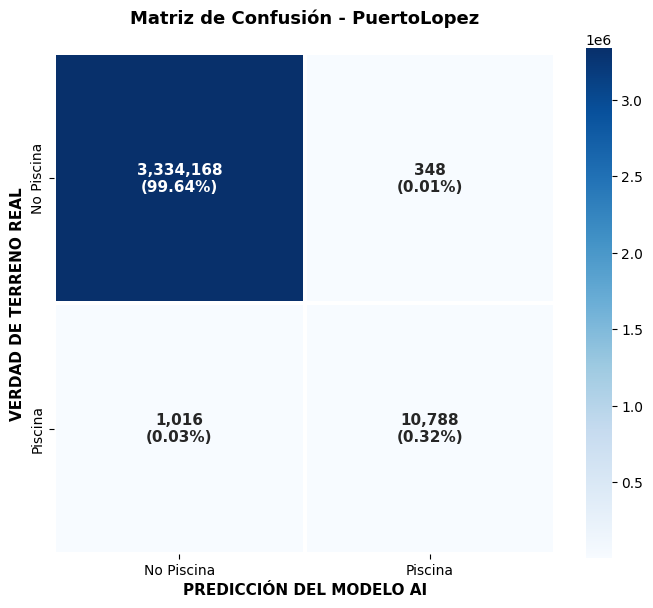

In [ ]:
import os, cv2, rasterio, geopandas as gpd, numpy as np, tensorflow as tf
import tensorflow.keras.backend as K
from tqdm import tqdm
from rasterio.mask import geometry_mask
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

# Funciones y Configuración
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f, y_pred_f = K.flatten(y_true), K.flatten(y_pred)
    return (2. * K.sum(y_true_f * y_pred_f) + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    return 0.3 * tf.keras.losses.binary_crossentropy(y_true, y_pred) + 0.7 * (1 - dice_coef(y_true, y_pred))

BASE_DIR = '/content/Datos_clase'
model_path = os.path.join(BASE_DIR, 'Modelos/Piscinas/best_model.h5')
tif_path = os.path.join(BASE_DIR, 'Datos/Imagen/PuertoLopez_clip.tif')
nombre_escena = os.path.basename(tif_path).split('_')[0]
size = 256

# Modelo e Inferencia
model = build_unet_model((size, size, 3), backbone_name='vgg16', freeze_backbone=True)
model.compile(optimizer='adam', loss=bce_dice_loss)
model.load_weights(model_path)

with rasterio.open(tif_path) as src:
    img = np.stack((src.read(4), src.read(2), src.read(1)), axis=-1).astype(np.float32) / 255.0
    h, w = img.shape[:2]
    mask_nodata = (src.read(1) == 0) & (src.read(2) == 0) & (src.read(3) == 0)
    transform, crs = src.transform, src.crs

truth = geometry_mask([g for g in gpd.read_file(os.path.join(BASE_DIR, 'Datos/Vectores/Piscina_clip_PL.shp')).to_crs(crs).geometry],
                      out_shape=(h, w), transform=transform, invert=True)

pad_y, pad_x = (size - h % size) % size, (size - w % size) % size
pad_img = np.pad(img, ((0, pad_y), (0, pad_x), (0, 0)))
preds = np.zeros((pad_img.shape[0], pad_img.shape[1]))

for y in tqdm(range(0, pad_img.shape[0], size), desc="Inferencia"):
    for x in range(0, pad_img.shape[1], size):
        if (y + size) <= pad_img.shape[0] and (x + size) <= pad_img.shape[1]:
            preds[y:y+size, x:x+size] = model.predict(np.expand_dims(pad_img[y:y+size, x:x+size], 0), verbose=0).squeeze()

final = cv2.morphologyEx(cv2.GaussianBlur((preds[:h, :w] > 0.6).astype(np.uint8), (3, 3), 0), cv2.MORPH_CLOSE, np.ones((3, 3)))
ret, labels = cv2.connectedComponents(final)
for l in range(1, ret):
    if np.sum(labels == l) < 50: final[labels == l] = 0
final[mask_nodata] = 0

# Evaluación y Visualización
valid = ~mask_nodata.flatten()
gt, p = truth.flatten()[valid], final.flatten()[valid]
cm = confusion_matrix(gt, p)
porcentajes = (cm / np.sum(cm)) * 100
lbls = np.array([[f"{cm[0,0]:,.0f}\n({porcentajes[0,0]:.2f}%)", f"{cm[0,1]:,.0f}\n({porcentajes[0,1]:.2f}%)"],
                 [f"{cm[1,0]:,.0f}\n({porcentajes[1,0]:.2f}%)", f"{cm[1,1]:,.0f}\n({porcentajes[1,1]:.2f}%)"]])

print(f"\n================ METRICAS {nombre_escena.upper()} ================")
print(f"Precisión: {precision_score(gt, p):.4f} | Recall: {recall_score(gt, p):.4f} | F1: {f1_score(gt, p):.4f}")

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=lbls, fmt="", cmap="Blues", square=True, annot_kws={"size": 11, "weight": "bold"}, linewidths=1.5, linecolor="white")
plt.title(f"Matriz de Confusión - {nombre_escena}\n", fontsize=13, weight='bold')
plt.xlabel('PREDICCIÓN DEL MODELO AI', fontsize=11, weight='bold')
plt.ylabel('VERDAD DE TERRENO REAL', fontsize=11, weight='bold')
plt.gca().set_xticklabels(['No Piscina', 'Piscina'])
plt.gca().set_yticklabels(['No Piscina', 'Piscina'], va='center')
plt.tight_layout()
plt.show()

## **VECTORIZACIÓN DE PISCINAS**

In [ ]:
from rasterio import features
from shapely.geometry import shape

print(f"Vectorizando {nombre_escena}...")
polygons = [shape(geom) for geom, val in features.shapes(final, mask=(final == 1), transform=transform)]

if polygons:
    gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=crs)
    gdf = gdf[gdf.is_valid & ~gdf.is_empty].copy()

    # Aplicar rectángulo y buffer correctamente
    # Usamos .apply para transformar cada geometría individualmente
    gdf['geometry'] = gdf.geometry.apply(lambda geom: geom.minimum_rotated_rectangle.buffer(-0.2))

    # Limpieza final
    gdf = gdf[gdf.is_valid & ~gdf.is_empty]

    path = os.path.join(output_dir, f"Vector_Piscinas_{nombre_escena}.shp")
    gdf.to_file(path)
    print(f"Éxito: {len(gdf)} piscinas guardadas en {path}")
else:
    print("Advertencia: No se encontraron piscinas.")

Vectorizando PuertoLopez...
Éxito: 9 piscinas guardadas en /content/Datos_clase/Resultados_Piscinas/Vector_Piscinas_PuertoLopez.shp
